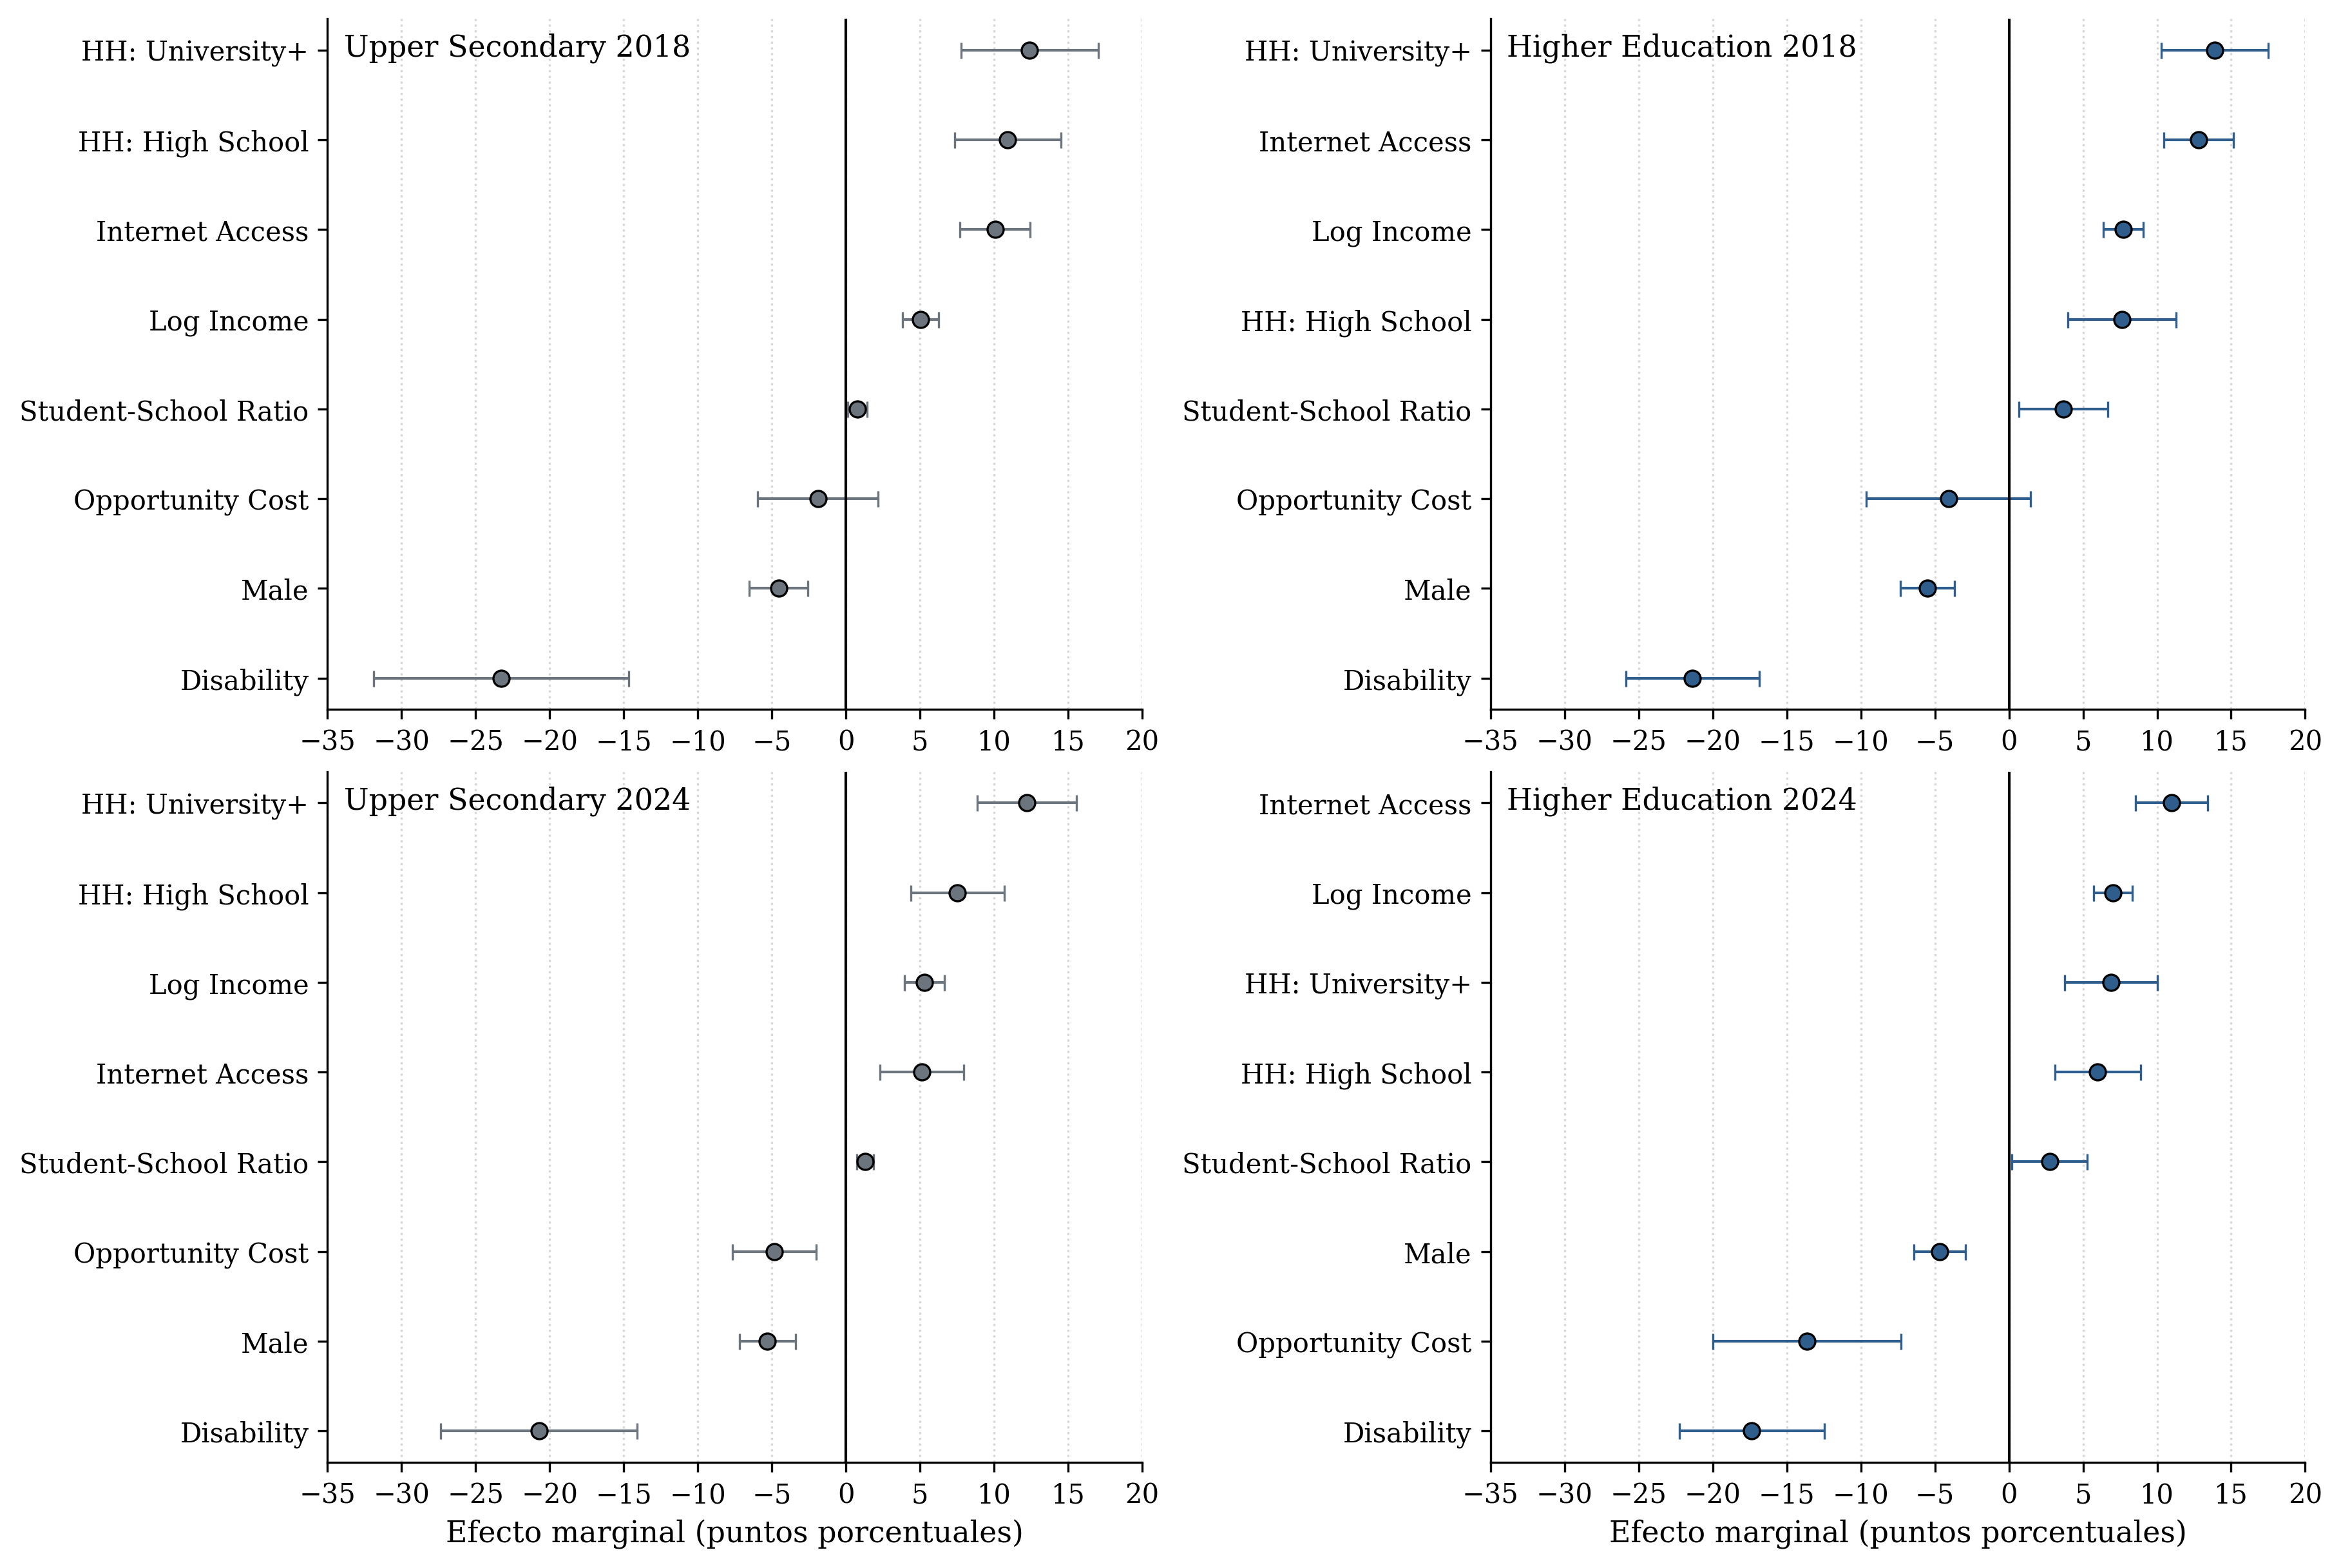

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '4.1'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =============================================
# RECONSTRUCCIÓN DE DATOS (proporcionada por el usuario)
# =============================================
variables = [
    'Disability',
    'Log Income',
    'Non-study Hours',
    'HH: Primary',
    'HH: Secondary',
    'HH: High School',
    'HH: University+',
    'Internet Access',
    'Male',
    'Age',
    'Indigenous',
    'Urban',
    'Household Size',
    'Region: Central-North',
    'Region: North',
    'Region: Northwest',
    'Region: South',
    'Student-School Ratio',
    'Opportunity Cost'
]

data = {
    'Variable': variables * 4,
    'Model': (
        ['Upper Secondary 2018'] * 19 +
        ['Higher Education 2018'] * 19 +
        ['Upper Secondary 2024'] * 19 +
        ['Higher Education 2024'] * 19
    ),
    'Effect': [
        # Upper Secondary 2018
        -0.2328, 0.0503, -0.0045, 0.0180, 0.0495,
        0.1093, 0.1240, 0.1007, -0.0455, -0.0367,
        0.0013, 0.0314, -0.0144, -0.0465, -0.0238,
        0.0167, 0.0484, 0.0077, -0.0189,
        # Higher Education 2018
        -0.2138, 0.0772, -0.0049, -0.0601, -0.0006,
        0.0762, 0.1389, 0.1282, -0.0552, -0.0510,
        -0.0024, 0.0432, -0.0152, -0.0423, -0.0216,
        0.0217, 0.0248, 0.0367, -0.0408,
        # Upper Secondary 2024
        -0.2072, 0.0532, -0.0061, -0.0516, 0.0118,
        0.0753, 0.1222, 0.0513, -0.0530, -0.0275,
        0.0065, 0.0339, -0.0100, -0.0430, -0.0463,
        0.0011, 0.0007, 0.0128, -0.0484,
        # Higher Education 2024
        -0.1736, 0.0702, -0.0078, -0.0632, -0.0122,
        0.0599, 0.0689, 0.1097, -0.0469, -0.0324,
        -0.0005, 0.0466, -0.0172, -0.0240, -0.0115,
        0.0008, -0.0360, 0.0274, -0.1365
    ]
}

df = pd.DataFrame(data)

# Estadísticos t
t_stats = {
    'Upper Secondary 2018': [-5.30, 8.09, -17.76, 1.17, 3.45, 5.96, 5.24, 8.34, -4.46, -6.84, 0.11, 2.48, -4.35, -2.55, -1.70, 1.16, 2.91, 2.29, -0.91],
    'Higher Education 2018': [-9.31, 11.20, -25.23, -3.73, -0.05, 4.08, 7.51, 10.72, -5.93, -21.97, -0.19, 3.39, -5.01, -2.54, -1.41, 1.55, 1.60, 2.40, -1.44],
    'Upper Secondary 2024': [-6.13, 7.74, -20.52, -2.80, 0.72, 4.68, 7.12, 3.58, -5.52, -5.17, 0.49, 2.78, -2.78, -2.54, -3.27, 0.09, 0.05, 4.44, -3.36],
    'Higher Education 2024': [-6.95, 10.48, -46.31, -3.98, -0.96, 4.06, 4.33, 8.86, -5.26, -13.97, -0.05, 4.00, -5.14, -1.57, -0.70, 0.07, -2.76, 2.10, -4.22]
}

# =============================================
# FUNCIÓN PARA CALCULAR EL INTERVALO DE CONFIANZA (95%)
# =============================================
def compute_ci(effect, t):
    se = abs(effect / t) if t != 0 else 0.0
    return 1.96 * se

# =============================================
# VARIABLES SELECCIONADAS PARA EL FOREST PLOT
# =============================================
selected_variables = [
    'HH: University+',
    'HH: High School',
    'Internet Access',
    'Male',
    'Disability',
    'Log Income',
    'Opportunity Cost',
    'Student-School Ratio'
]

# =============================================
# CONFIGURACIÓN DE COLORES
# =============================================
color_upper = '#6C757D'    # Media Superior
color_higher = '#2F5D8C'   # Superior

# =============================================
# RANGO FIJO DEL EJE X
# =============================================
x_min = -35
x_max = 20
x_ticks = np.arange(x_min, x_max + 1, 5)

# =============================================
# CREACIÓN DEL FOREST PLOT (2×2)
# =============================================
models = [
    'Upper Secondary 2018',
    'Higher Education 2018',
    'Upper Secondary 2024',
    'Higher Education 2024'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

for idx, ax in enumerate(axes):
    mod = models[idx]
    df_mod = df[
        (df['Model'] == mod) &
        (df['Variable'].isin(selected_variables))
    ].copy()

    # Efecto en puntos porcentuales
    df_mod['Effect'] = df_mod['Effect'] * 100
    df_mod = df_mod.sort_values('Effect', ascending=True)

    labels = [textwrap.fill(v, width=22) for v in df_mod['Variable']]
    y_pos = np.arange(len(labels))

    tvals = [t_stats[mod][variables.index(v)] for v in df_mod['Variable']]
    ci_vals = [compute_ci(eff, t) for eff, t in zip(df_mod['Effect'], tvals)]

    color = color_upper if 'Upper' in mod else color_higher

    # Puntos + barras de error
    ax.errorbar(
        df_mod['Effect'],
        y_pos,
        xerr=ci_vals,
        fmt='o',
        color=color,
        markerfacecolor=color,
        markeredgecolor='black',
        markeredgewidth=0.8,
        capsize=3,
        elinewidth=1,
        capthick=1
    )

    # Línea vertical en cero
    ax.axvline(0, color='black', linewidth=1)

    # Configuración de ejes
    ax.set_xlim(x_min, x_max)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)

    # Rejilla en el eje X
    ax.grid(axis='x', linestyle=':', alpha=0.5)

    # Eliminar spines superiores y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Etiqueta identificadora del panel (sin título formal)
    ax.text(0.02, 0.98, mod, transform=ax.transAxes,
            fontsize=11, va='top', ha='left')

    # Etiqueta del eje X (solo para los paneles inferiores para evitar redundancia)
    if idx >= 2:
        ax.set_xlabel('Efecto marginal (puntos porcentuales)')
    else:
        ax.set_xlabel('')  # vacío en los superiores

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

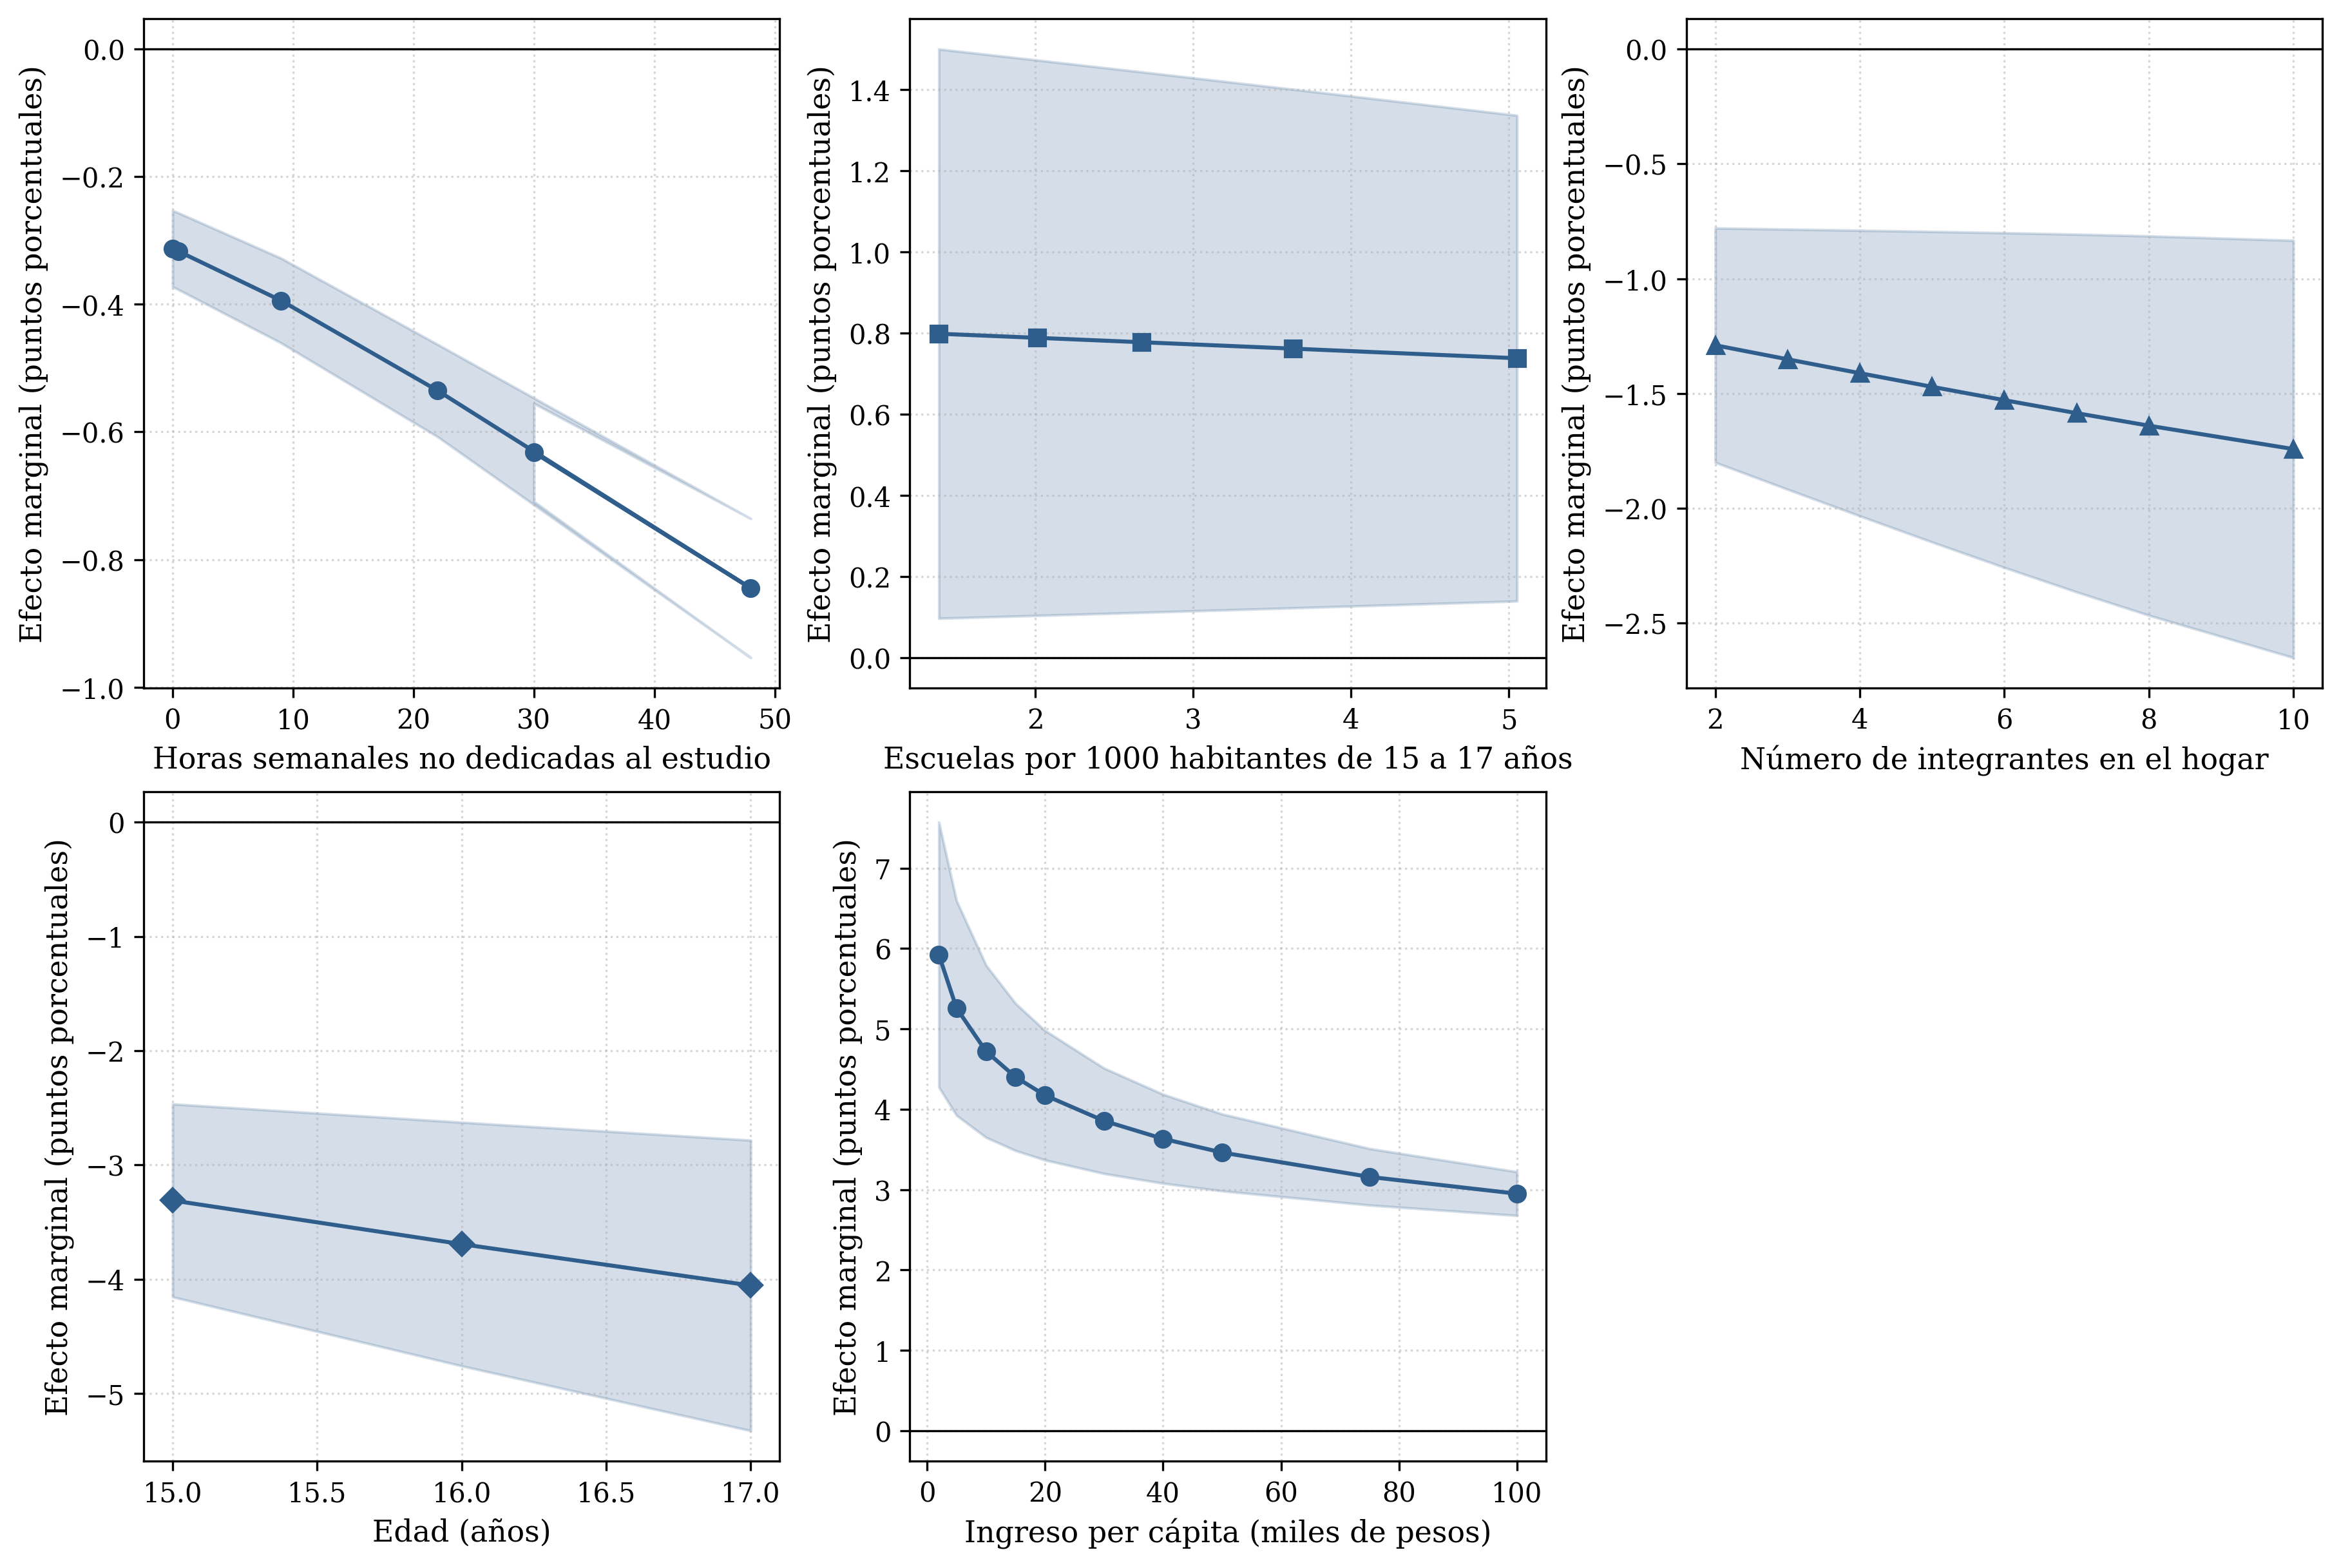

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '4.2'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# Color principal para la serie (una sola serie -> azul oscuro)
color_serie = '#2F5D8C'

# =============================================
# DATOS DEL MODELO (Upper Secondary 2018)
# =============================================

# 1. Horas no estudio
horas_x = np.array([0, 0.5, 9, 22, 48, 30])
horas_dydx = np.array([-0.0031285, -0.0031698, -0.0039411, -0.0053526, -0.0084492, -0.0063226])
horas_se   = np.array([0.0003048, 0.0003070, 0.0003388, 0.0003693, 0.0005560, 0.0003919])
horas_ci = 1.96 * horas_se

# 2. Razón escuelas / joven (inversa)
razon_x = np.array([1.388156, 2.01268, 2.67344, 3.631478, 5.050505])
razon_dydx = np.array([0.0079868, 0.0078855, 0.0077775, 0.0076194, 0.0073827])
razon_se   = np.array([0.0035801, 0.0034928, 0.0033992, 0.0032617, 0.0030548])
razon_ci = 1.96 * razon_se

# 3. Integrantes del hogar
integ_x = np.array([2, 3, 4, 5, 6, 7, 8, 10])
integ_dydx = np.array([-0.0129018, -0.013513, -0.0141176, -0.0147124, -0.0152943, -0.0158597, -0.0164054, -0.017424])
integ_se   = np.array([0.0026044, 0.0028908, 0.0031741, 0.0034514, 0.0037195, 0.0039753, 0.0042156, 0.0046374])
integ_ci = 1.96 * integ_se

# 4. Edad
edad_x = np.array([15, 16, 17])
edad_dydx = np.array([-0.0331082, -0.0369306, -0.040549])
edad_se   = np.array([0.0043073, 0.0054392, 0.006486])
edad_ci = 1.96 * edad_se

# 5. Ingreso (escala original en miles de pesos)
ln_niveles = np.array([0.6931472, 1.609438, 2.302585, 2.70805, 2.995732, 3.401197, 3.688879, 3.912023, 4.317488, 4.60517])
ingreso_miles = np.exp(ln_niveles)
ingreso_dydx = np.array([0.059229, 0.0525781, 0.0472047, 0.044005, 0.0417326, 0.0385504, 0.0363213, 0.0346155, 0.0315821, 0.0294914])
ingreso_se   = np.array([0.00841, 0.0068087, 0.005466, 0.0046692, 0.0041105, 0.0033453, 0.002826, 0.0024411, 0.0017943, 0.0013899])
ingreso_ci = 1.96 * ingreso_se

# =============================================
# CREACIÓN DE SUBPLOTS (2 filas × 3 columnas)
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

# --- Subplot 0: Horas no estudio ---
ax = axes[0]
ax.plot(horas_x, horas_dydx * 100, marker='o', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(horas_x, (horas_dydx - horas_ci) * 100, (horas_dydx + horas_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Horas semanales no dedicadas al estudio')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 1: Razón escuelas/joven ---
ax = axes[1]
ax.plot(razon_x, razon_dydx * 100, marker='s', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(razon_x, (razon_dydx - razon_ci) * 100, (razon_dydx + razon_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Escuelas por 1000 habitantes de 15 a 17 años')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 2: Integrantes del hogar ---
ax = axes[2]
ax.plot(integ_x, integ_dydx * 100, marker='^', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(integ_x, (integ_dydx - integ_ci) * 100, (integ_dydx + integ_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Número de integrantes en el hogar')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 3: Edad ---
ax = axes[3]
ax.plot(edad_x, edad_dydx * 100, marker='D', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(edad_x, (edad_dydx - edad_ci) * 100, (edad_dydx + edad_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 4: Ingreso (escala original) ---
ax = axes[4]
ax.plot(ingreso_miles, ingreso_dydx * 100, marker='o', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(ingreso_miles, (ingreso_dydx - ingreso_ci) * 100, (ingreso_dydx + ingreso_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Ingreso per cápita (miles de pesos)')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 5: vacío, se oculta ---
axes[5].set_visible(False)

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

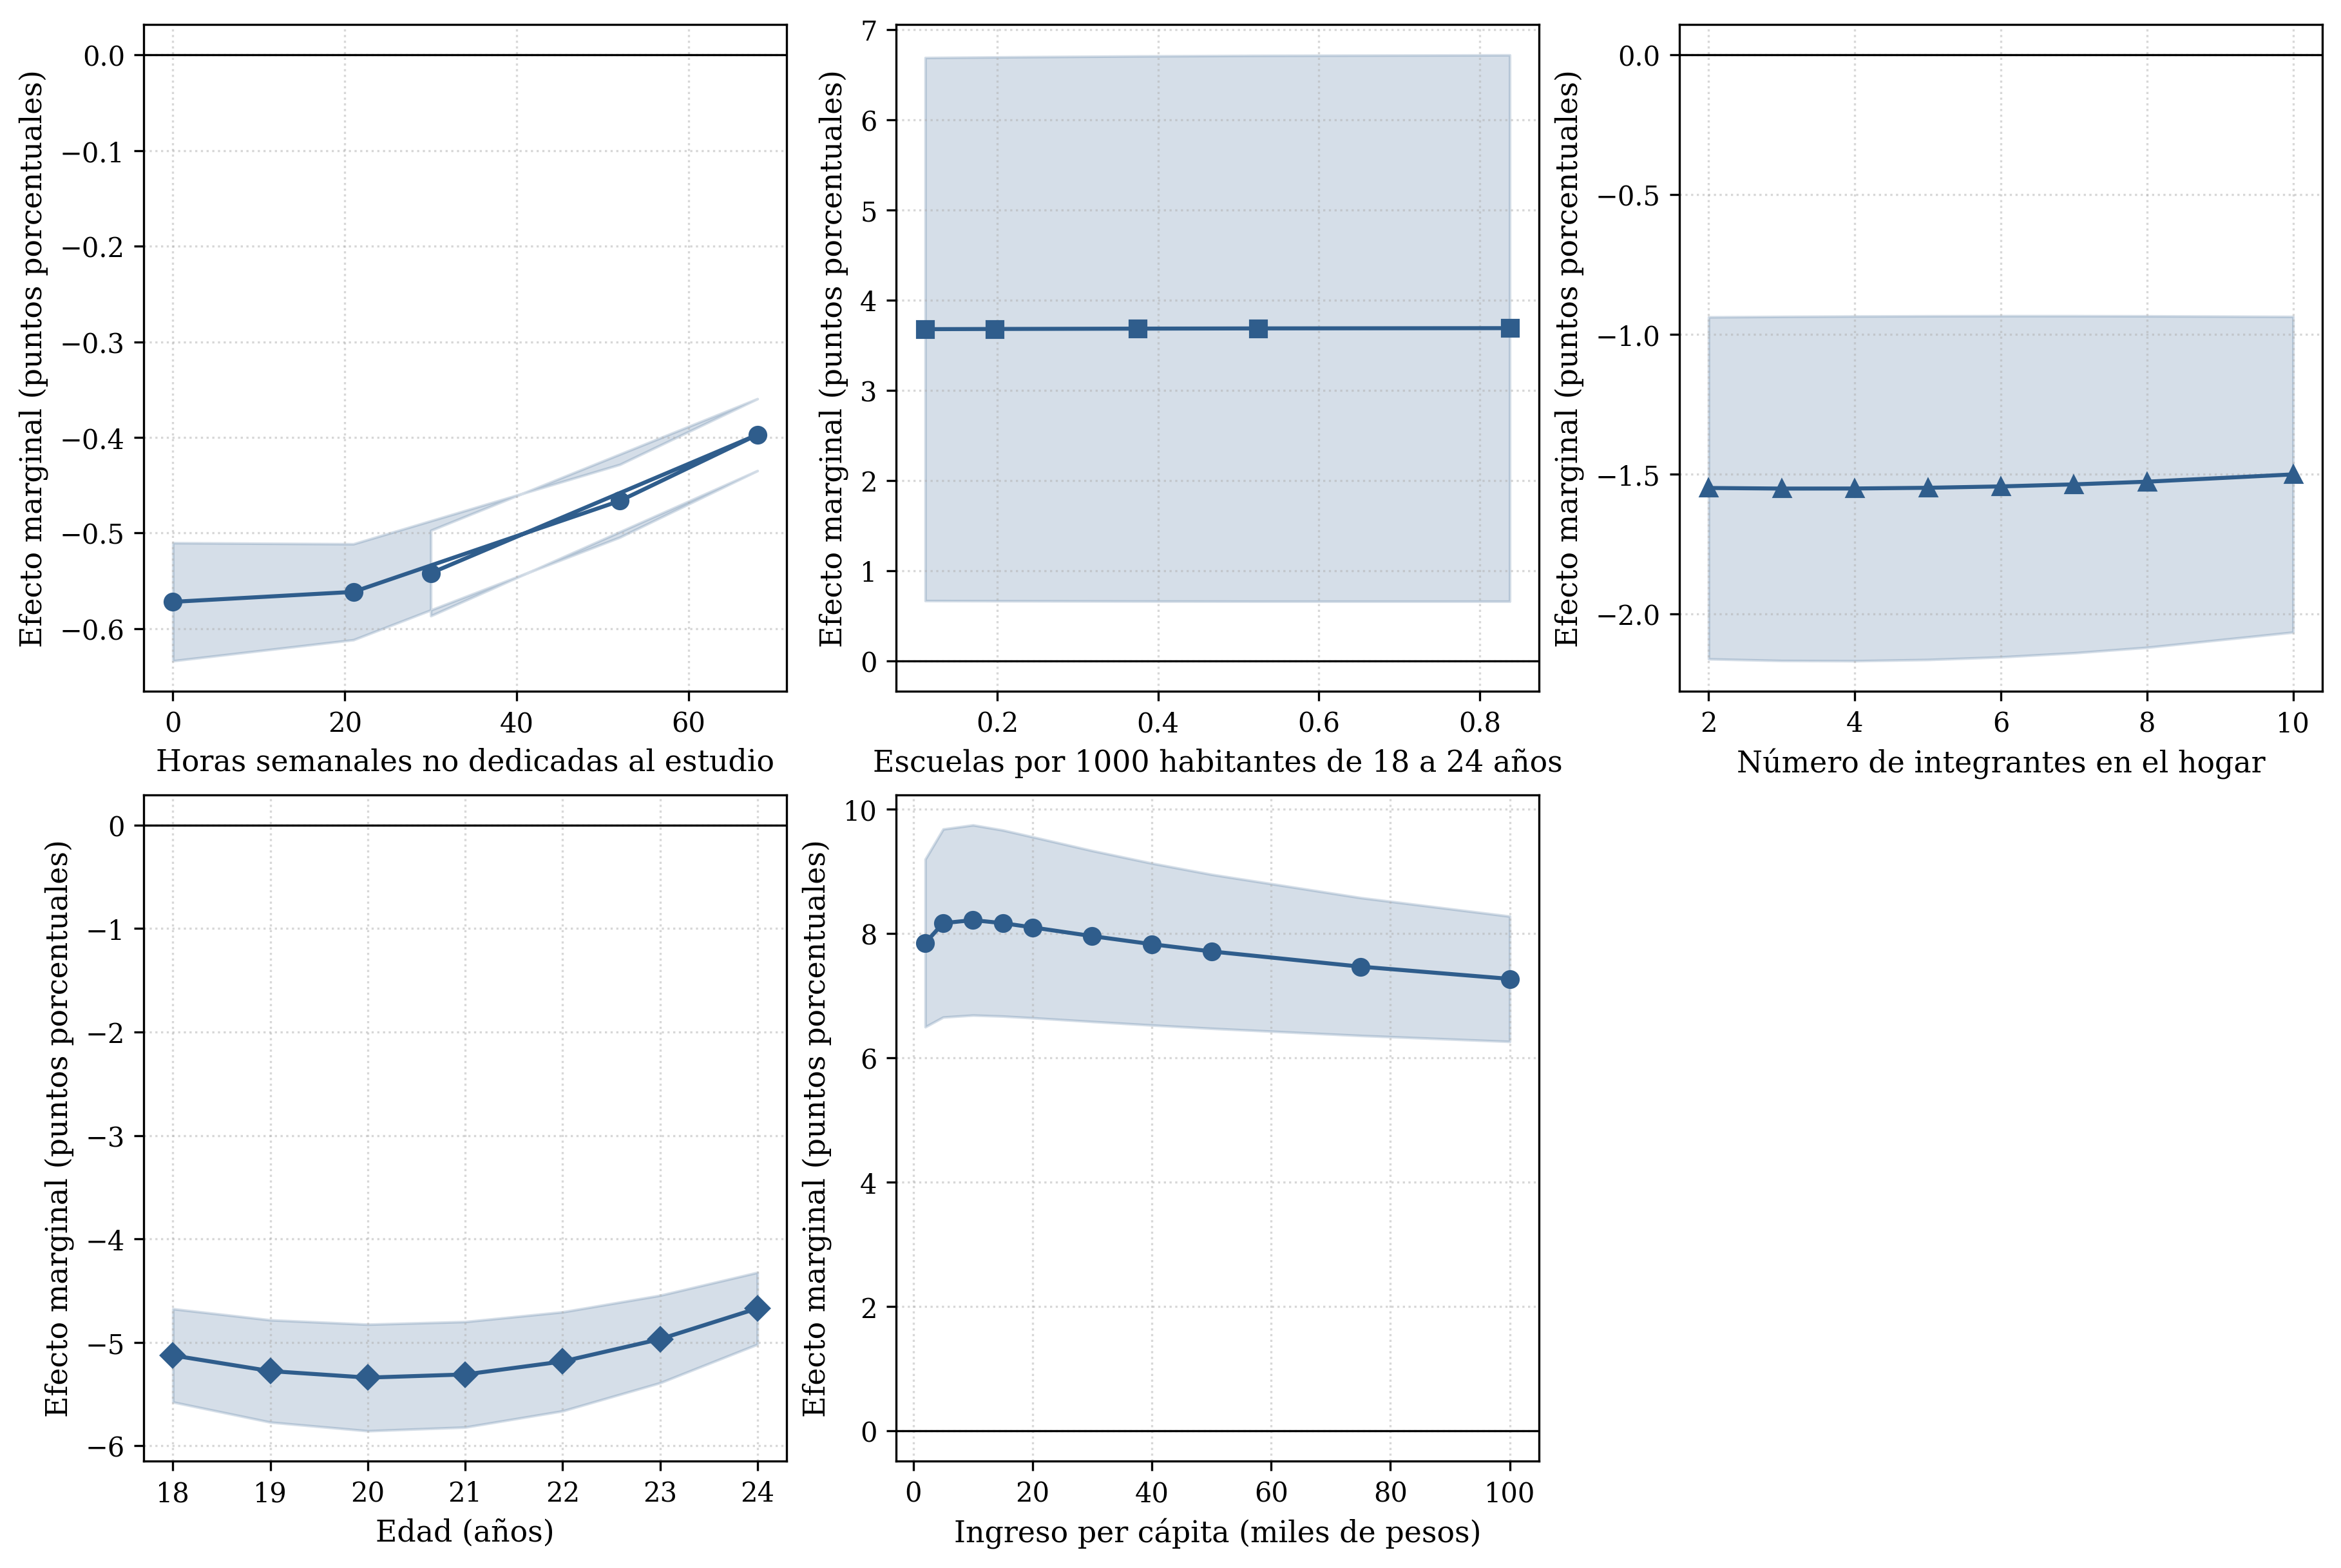

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '4.3'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# Color principal para la serie (una sola serie -> azul oscuro)
color_serie = '#2F5D8C'

# =============================================
# DATOS DEL MODELO (Higher Education 2018)
# =============================================

# 1. Horas no estudio
horas_x = np.array([0, 21, 52, 68, 30])
horas_dydx = np.array([-0.0057192, -0.005615, -0.004663, -0.0039715, -0.0054188])
horas_se   = np.array([0.0003148, 0.0002559, 0.0001941, 0.0001919, 0.0002279])
horas_ci = 1.96 * horas_se

# 2. Razón escuelas/joven (Superior)
razon_x = np.array([0.1104769, 0.1969345, 0.3746315, 0.5245433, 0.8373456])
razon_dydx = np.array([0.0367623, 0.0367846, 0.0368229, 0.0368474, 0.036876])
razon_se   = np.array([0.0153556, 0.0153775, 0.0154132, 0.0154336, 0.0154476])
razon_ci = 1.96 * razon_se

# 3. Integrantes del hogar
integ_x = np.array([2, 3, 4, 5, 6, 7, 8, 10])
integ_dydx = np.array([-0.0154855, -0.0155064, -0.015504, -0.0154783,
                       -0.0154291, -0.0153564, -0.0152604, -0.0149996])
integ_se   = np.array([0.0031199, 0.0031392, 0.0031446, 0.0031357,
                       0.0031126, 0.0030753, 0.0030239, 0.00288])
integ_ci = 1.96 * integ_se

# 4. Edad (18 a 24 años)
edad_x = np.array([18, 19, 20, 21, 22, 23, 24])
edad_dydx = np.array([-0.0512572, -0.0527691, -0.0533999, -0.0530932,
                      -0.0518396, -0.0496808, -0.0467081])
edad_se   = np.array([0.0022977, 0.0025203, 0.0026262, 0.0026006,
                      0.0024407, 0.0021564, 0.0017718])
edad_ci = 1.96 * edad_se

# 5. Ingreso (escala original en miles de pesos)
ln_niveles = np.array([0.6931472, 1.609438, 2.302585, 2.70805, 2.995732,
                       3.401197, 3.688879, 3.912023, 4.317488, 4.60517])
ingreso_miles = np.exp(ln_niveles)
ingreso_dydx = np.array([0.0784557, 0.0816603, 0.0821456, 0.081657, 0.0809767,
                         0.0795705, 0.0782737, 0.0771082, 0.074662, 0.0726935])
ingreso_se   = np.array([0.0068798, 0.007715, 0.0078017, 0.0076352, 0.0074255,
                         0.0070115, 0.0066422, 0.0063176, 0.0056556, 0.00514])
ingreso_ci = 1.96 * ingreso_se

# =============================================
# CREACIÓN DE SUBPLOTS (2 filas × 3 columnas)
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

# --- Subplot 0: Horas no estudio ---
ax = axes[0]
ax.plot(horas_x, horas_dydx * 100, marker='o', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(horas_x, (horas_dydx - horas_ci) * 100, (horas_dydx + horas_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Horas semanales no dedicadas al estudio')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 1: Razón escuelas/joven (Superior) ---
ax = axes[1]
ax.plot(razon_x, razon_dydx * 100, marker='s', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(razon_x, (razon_dydx - razon_ci) * 100, (razon_dydx + razon_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Escuelas por 1000 habitantes de 18 a 24 años')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 2: Integrantes del hogar ---
ax = axes[2]
ax.plot(integ_x, integ_dydx * 100, marker='^', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(integ_x, (integ_dydx - integ_ci) * 100, (integ_dydx + integ_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Número de integrantes en el hogar')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 3: Edad ---
ax = axes[3]
ax.plot(edad_x, edad_dydx * 100, marker='D', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(edad_x, (edad_dydx - edad_ci) * 100, (edad_dydx + edad_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 4: Ingreso (escala original) ---
ax = axes[4]
ax.plot(ingreso_miles, ingreso_dydx * 100, marker='o', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(ingreso_miles, (ingreso_dydx - ingreso_ci) * 100, (ingreso_dydx + ingreso_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Ingreso per cápita (miles de pesos)')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 5: vacío, se oculta ---
axes[5].set_visible(False)

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

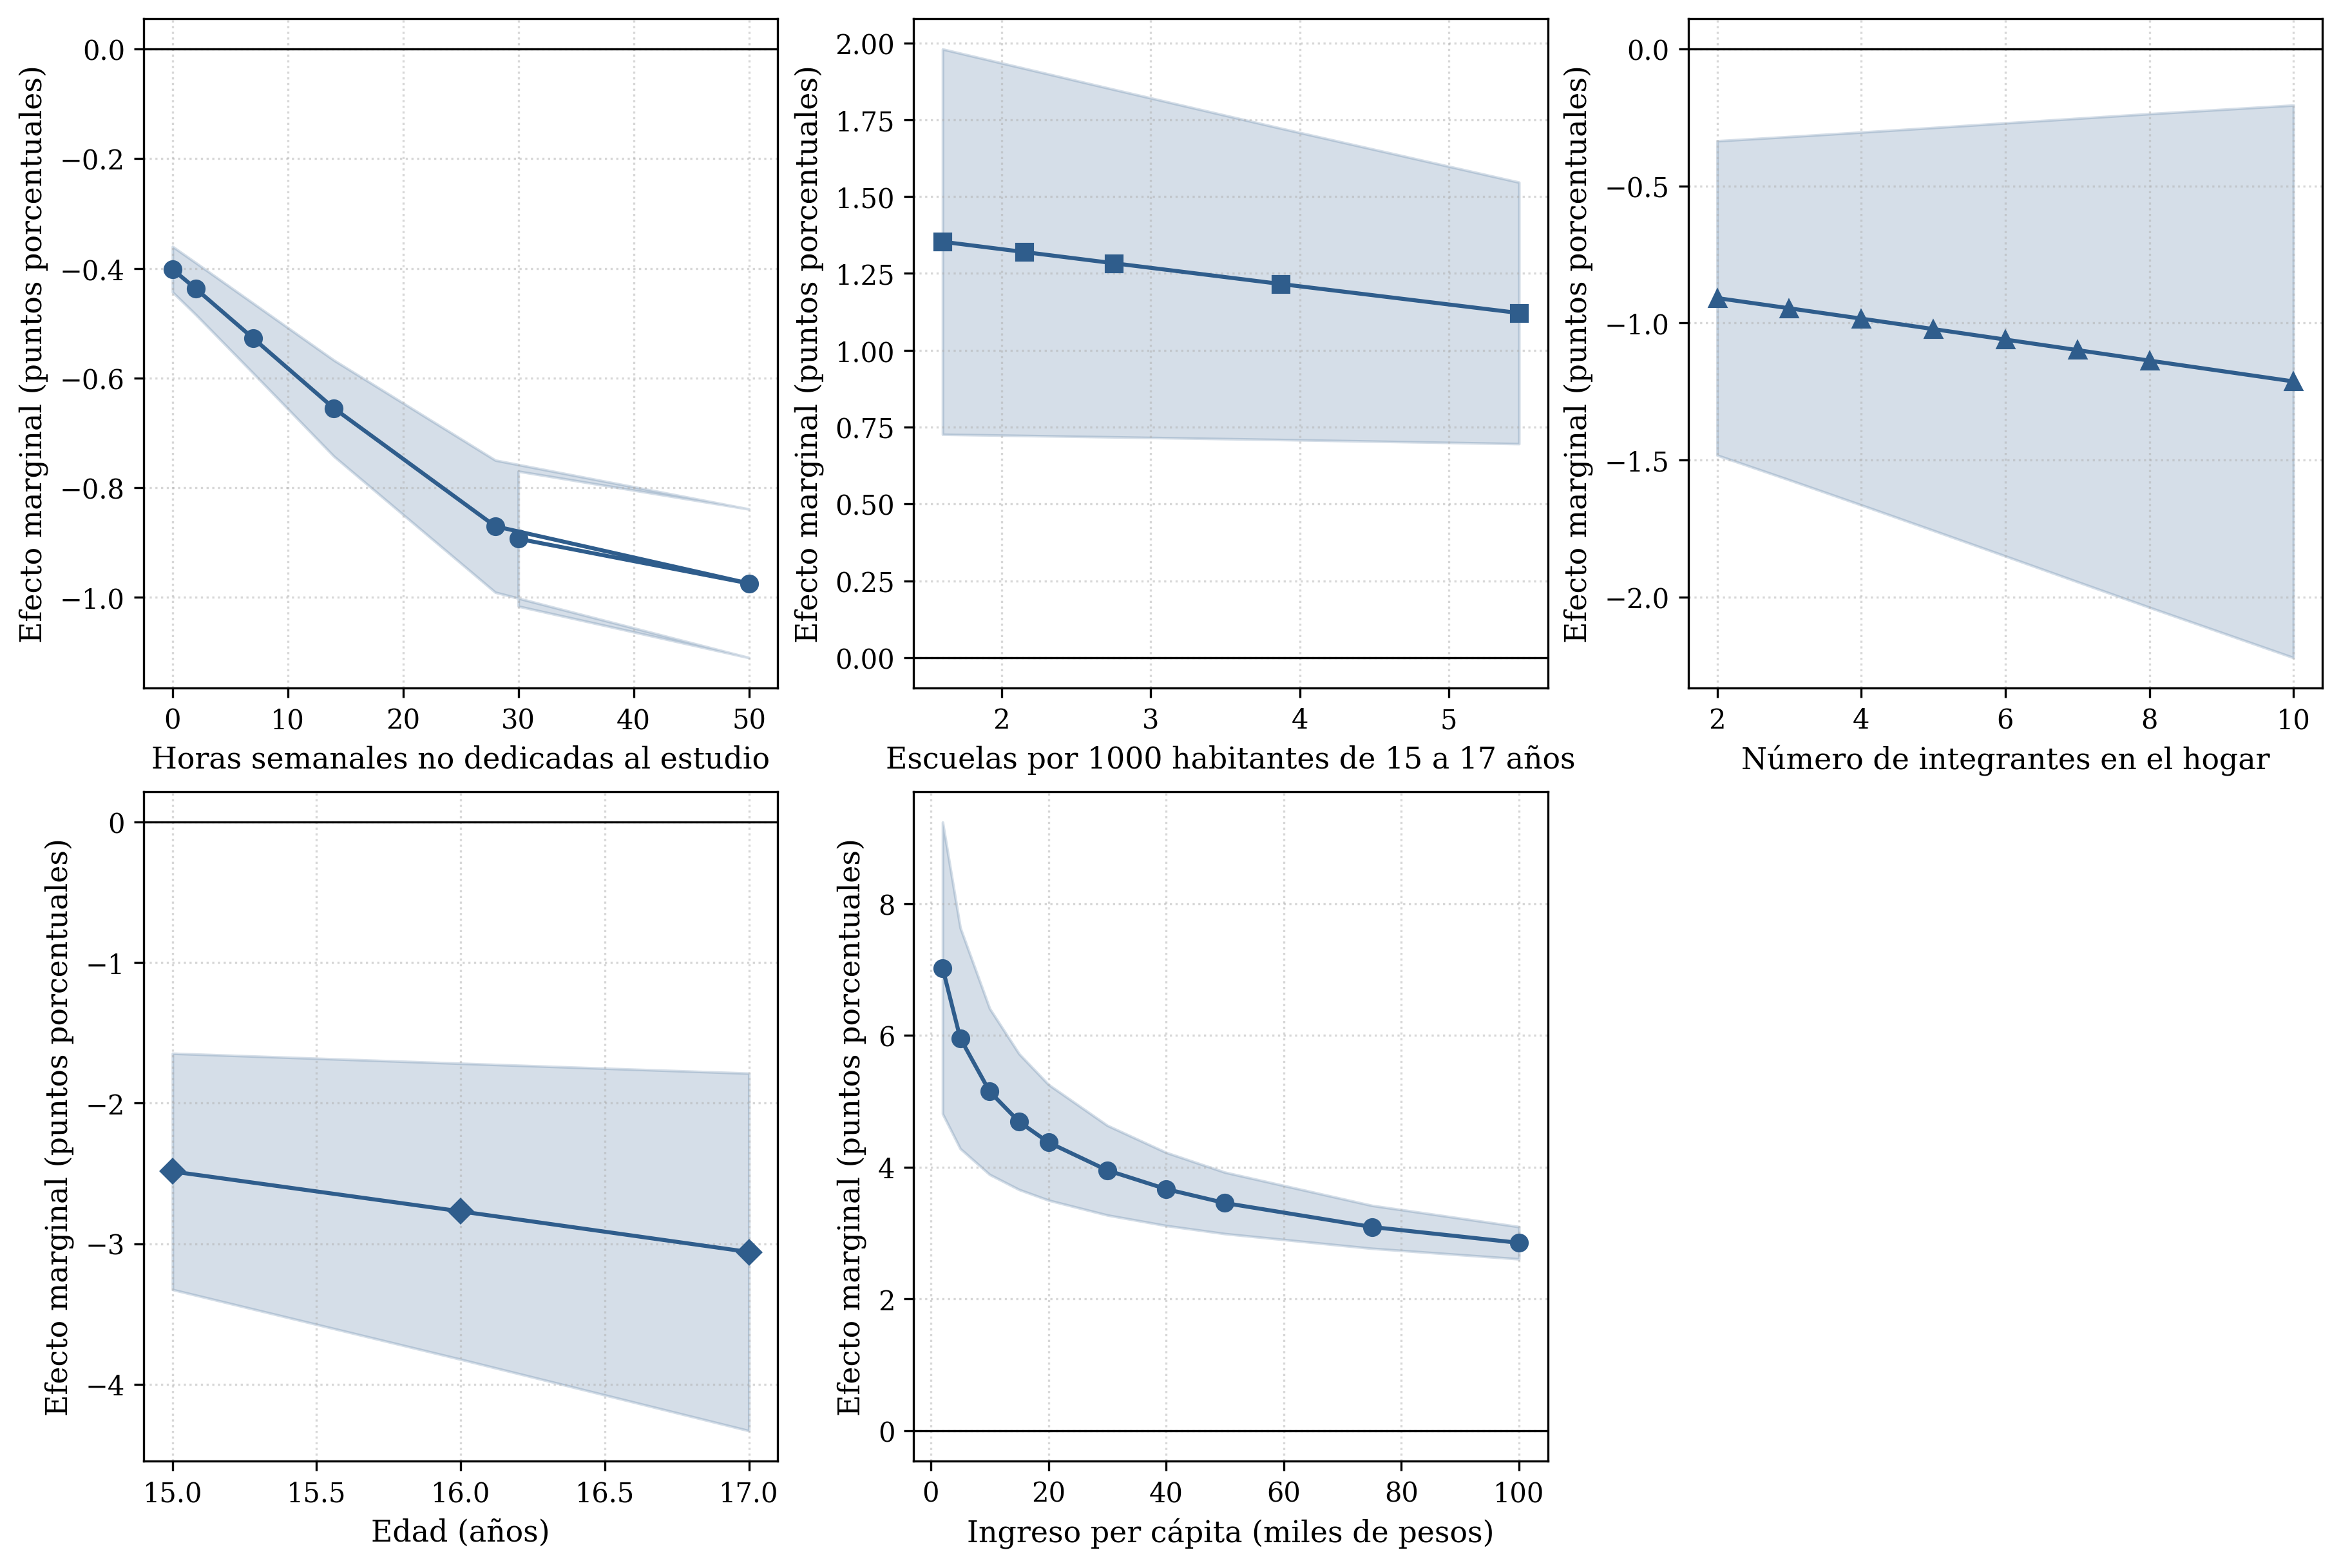

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '4.4'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# Color principal para la serie (una sola serie -> azul oscuro)
color_serie = '#2F5D8C'

# =============================================
# DATOS DEL MODELO (Upper Secondary 2024)
# =============================================

# 1. Horas no estudio
horas_x = np.array([0, 2, 7, 14, 28, 50, 30])
horas_dydx = np.array([-0.0040158, -0.004367, -0.0052742, -0.0065509,
                       -0.008703, -0.0097449, -0.008931])
horas_se = np.array([0.0002121, 0.0002412, 0.0003255, 0.0004473,
                     0.0006147, 0.0006914, 0.0006279])
horas_ci = 1.96 * horas_se

# 2. Razón escuelas/joven (inversa)
razon_x = np.array([1.604106, 2.150954, 2.754442, 3.871018, 5.469861])
razon_dydx = np.array([0.0135305, 0.0131971, 0.0128304, 0.0121572, 0.0112122])
razon_se = np.array([0.0031972, 0.0030479, 0.0028838, 0.0025842, 0.0021699])
razon_ci = 1.96 * razon_se

# 3. Integrantes del hogar
integ_x = np.array([2, 3, 4, 5, 6, 7, 8, 10])
integ_dydx = np.array([-0.0090878, -0.0094609, -0.0098386, -0.0102197,
                       -0.010603, -0.0109874, -0.0113714, -0.0121324])
integ_se = np.array([0.0029269, 0.0031965, 0.0034718, 0.0037513,
                     0.0040332, 0.0043157, 0.0045968, 0.0051454])
integ_ci = 1.96 * integ_se

# 4. Edad (15-17 años)
edad_x = np.array([15, 16, 17])
edad_dydx = np.array([-0.0248643, -0.0277029, -0.0305961])
edad_se = np.array([0.0042887, 0.0053735, 0.0064903])
edad_ci = 1.96 * edad_se

# 5. Ingreso (escala original en miles de pesos)
ln_niveles = np.array([0.6931472, 1.609438, 2.302585, 2.70805, 2.995732,
                       3.401197, 3.688879, 3.912023, 4.317488, 4.60517])
ingreso_miles = np.exp(ln_niveles)
ingreso_dydx = np.array([0.0702474, 0.0595932, 0.0514935, 0.0469132, 0.0437746,
                         0.0395415, 0.0366891, 0.0345692, 0.0309324, 0.0285239])
ingreso_se = np.array([0.0112961, 0.0085562, 0.0064299, 0.0052582, 0.00448,
                       0.0034741, 0.0028325, 0.0023794, 0.0016632, 0.0012485])
ingreso_ci = 1.96 * ingreso_se

# =============================================
# CREACIÓN DE SUBPLOTS (2 filas × 3 columnas)
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

# --- Subplot 0: Horas no estudio ---
ax = axes[0]
ax.plot(horas_x, horas_dydx * 100, marker='o', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(horas_x, (horas_dydx - horas_ci) * 100, (horas_dydx + horas_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Horas semanales no dedicadas al estudio')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 1: Razón escuelas/joven ---
ax = axes[1]
ax.plot(razon_x, razon_dydx * 100, marker='s', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(razon_x, (razon_dydx - razon_ci) * 100, (razon_dydx + razon_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Escuelas por 1000 habitantes de 15 a 17 años')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 2: Integrantes del hogar ---
ax = axes[2]
ax.plot(integ_x, integ_dydx * 100, marker='^', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(integ_x, (integ_dydx - integ_ci) * 100, (integ_dydx + integ_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Número de integrantes en el hogar')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 3: Edad ---
ax = axes[3]
ax.plot(edad_x, edad_dydx * 100, marker='D', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(edad_x, (edad_dydx - edad_ci) * 100, (edad_dydx + edad_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 4: Ingreso (escala original) ---
ax = axes[4]
ax.plot(ingreso_miles, ingreso_dydx * 100, marker='o', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(ingreso_miles, (ingreso_dydx - ingreso_ci) * 100, (ingreso_dydx + ingreso_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Ingreso per cápita (miles de pesos)')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 5: vacío, se oculta ---
axes[5].set_visible(False)

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

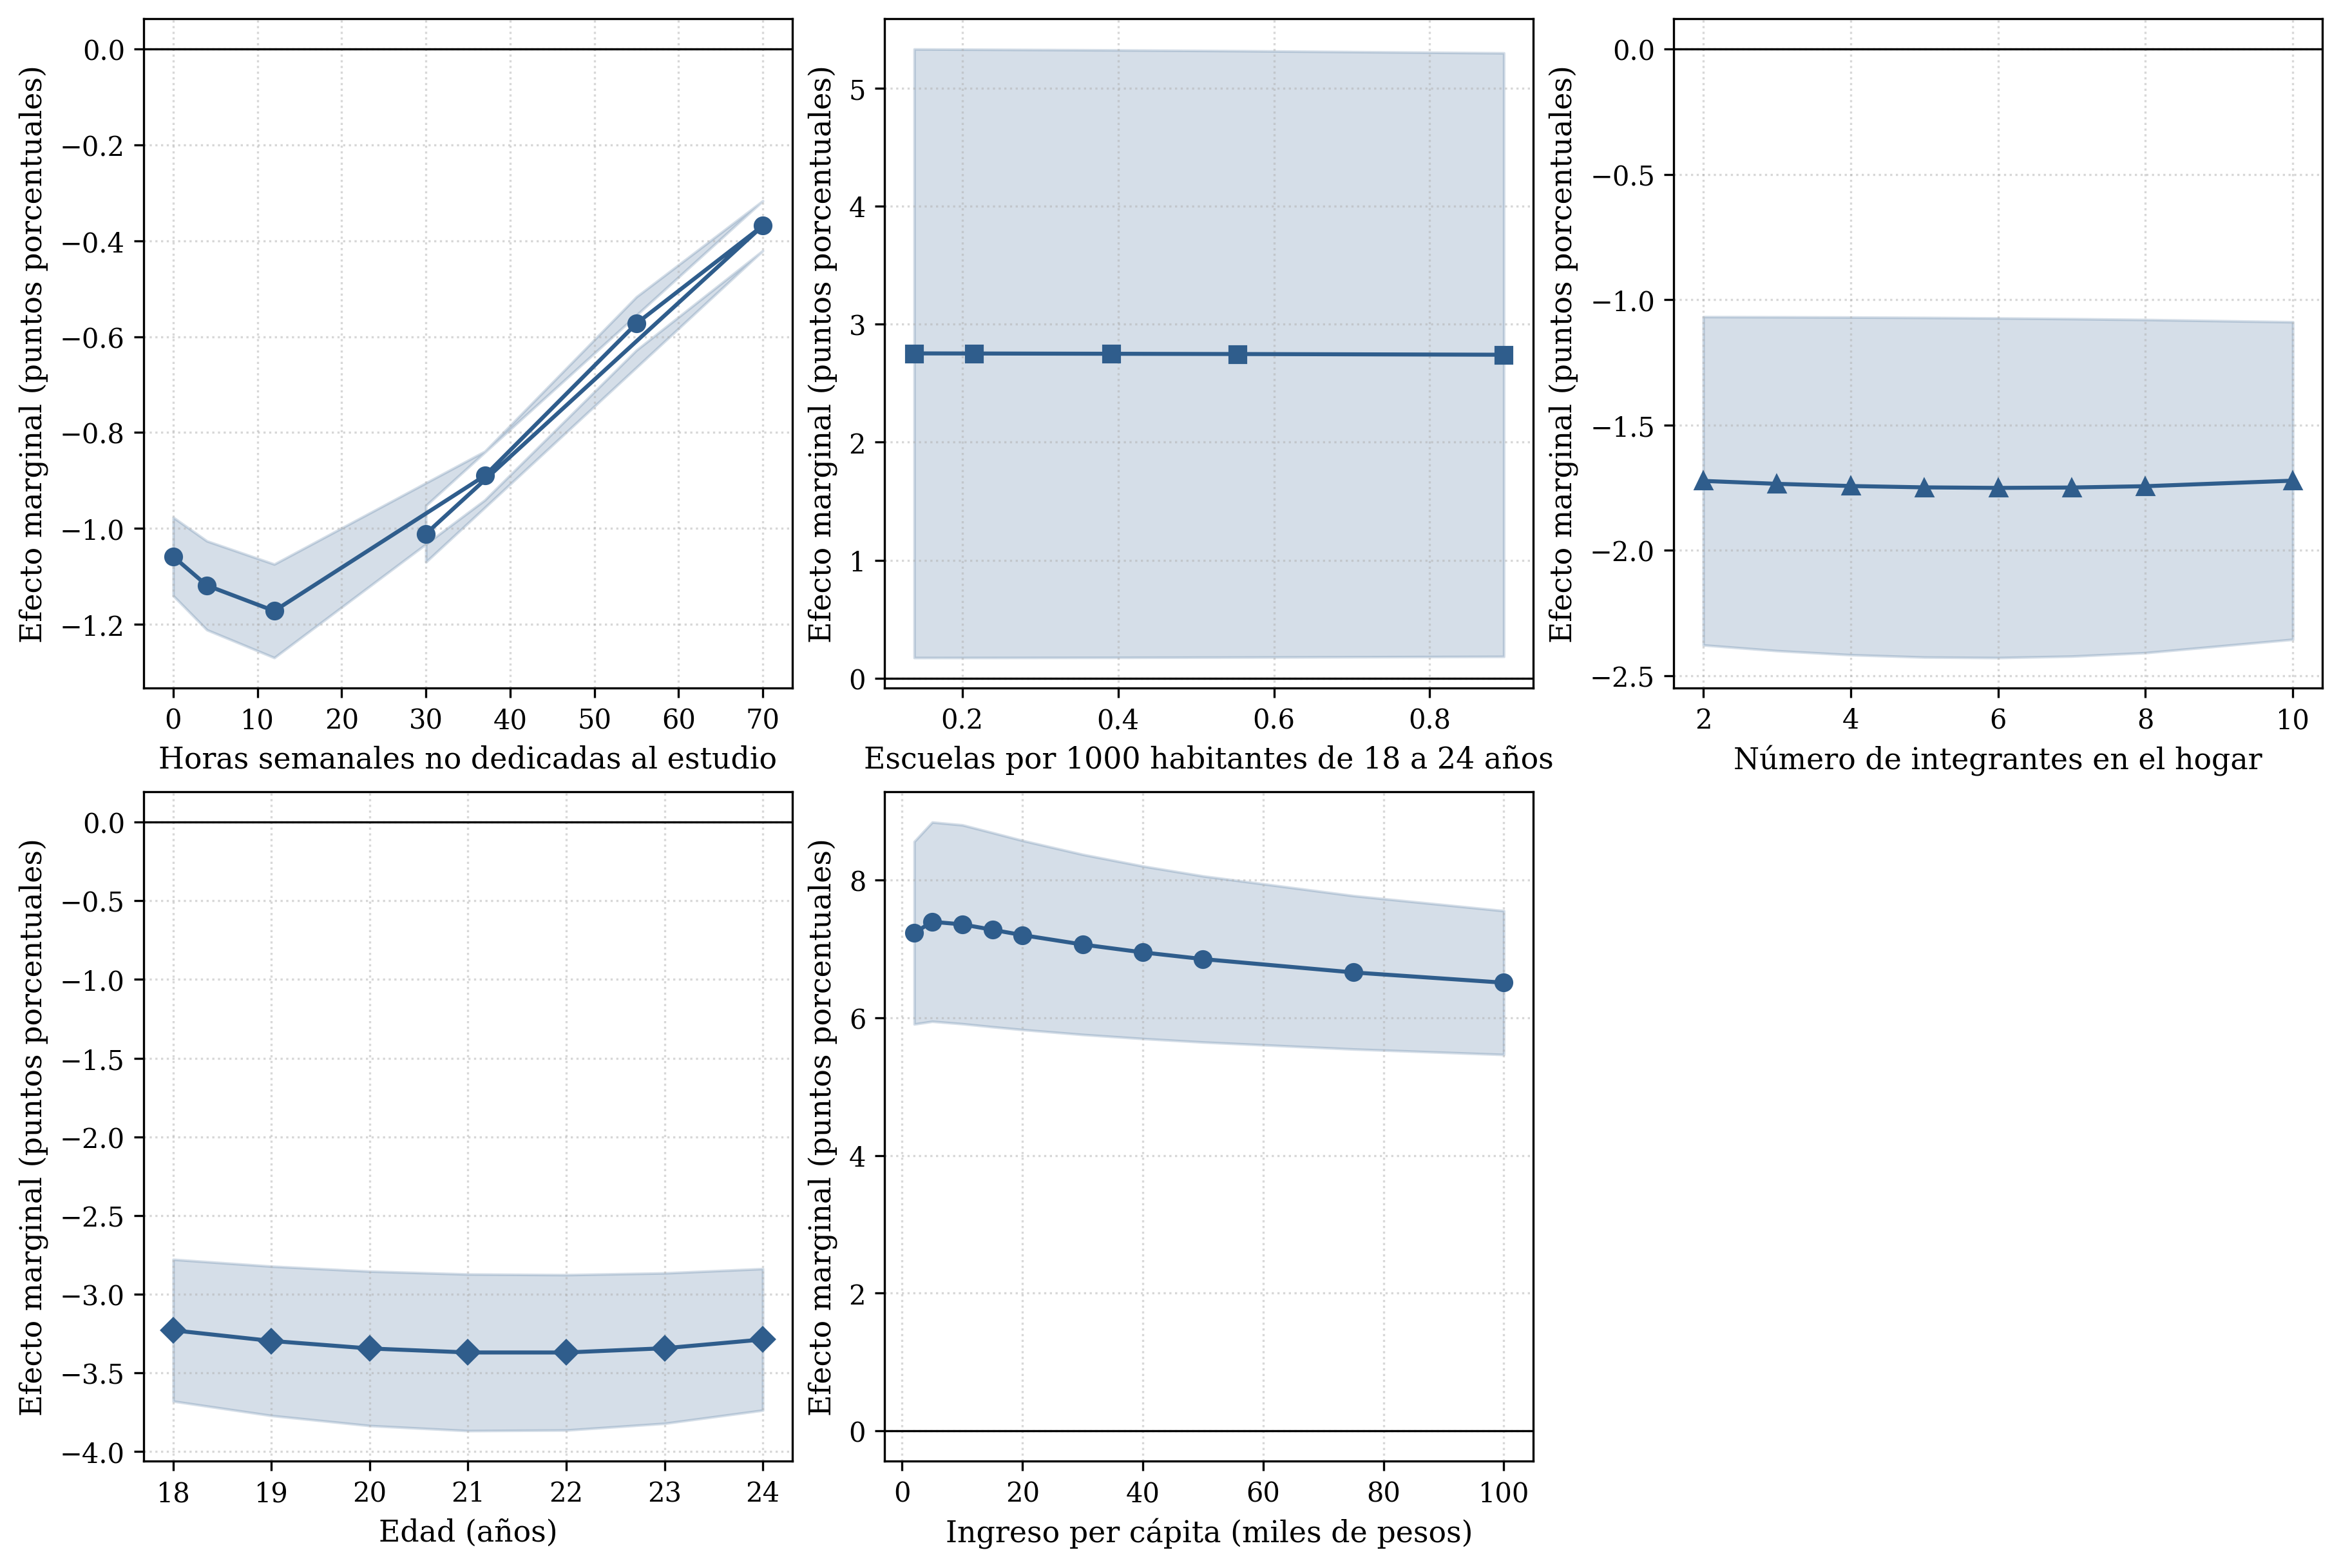

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '4.5'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# Color principal para la serie (una sola serie -> azul oscuro)
color_serie = '#2F5D8C'

# =============================================
# DATOS DEL MODELO (Higher Education 2024)
# =============================================

# 1. Horas no estudio
horas_x = np.array([0, 4, 12, 37, 55, 70, 30])
horas_dydx = np.array([-0.0105858, -0.0111898, -0.0117219, -0.0089003,
                       -0.0057249, -0.0036856, -0.0101126])
horas_se = np.array([0.0004168, 0.0004728, 0.0004977, 0.000259,
                     0.0002839, 0.000265, 0.0003003])
horas_ci = 1.96 * horas_se

# 2. Razón escuelas/joven (Superior)
razon_x = np.array([0.1382935, 0.2154244, 0.3909473, 0.5532809, 0.8950227])
razon_dydx = np.array([0.0275191, 0.027511, 0.0274896, 0.0274663, 0.0274063])
razon_se = np.array([0.0131555, 0.0131491, 0.0131305, 0.0131081, 0.0130456])
razon_ci = 1.96 * razon_se

# 3. Integrantes del hogar
integ_x = np.array([2, 3, 4, 5, 6, 7, 8, 10])
integ_dydx = np.array([-0.0172302, -0.0173473, -0.017434, -0.0174886,
                       -0.0175092, -0.0174941, -0.0174418, -0.0172209])
integ_se = np.array([0.0033419, 0.0033981, 0.003437, 0.0034571,
                     0.003457, 0.0034353, 0.0033911, 0.0032319])
integ_ci = 1.96 * integ_se

# 4. Edad (18-24 años)
edad_x = np.array([18, 19, 20, 21, 22, 23, 24])
edad_dydx = np.array([-0.0323012, -0.0329774, -0.0334562, -0.0337094,
                      -0.0337113, -0.0334413, -0.0328856])
edad_se = np.array([0.0022988, 0.0024212, 0.0025039, 0.002539,
                    0.002519, 0.0024385, 0.0022946])
edad_ci = 1.96 * edad_se

# 5. Ingreso (escala original en miles de pesos)
ln_niveles = np.array([0.6931472, 1.609438, 2.302585, 2.70805, 2.995732,
                       3.401197, 3.688879, 3.912023, 4.317488, 4.60517])
ingreso_miles = np.exp(ln_niveles)
ingreso_dydx = np.array([0.0723613, 0.0739689, 0.0735899, 0.0728086, 0.0720335,
                         0.0706654, 0.0695218, 0.0685476, 0.066608, 0.065118])
ingreso_se = np.array([0.006766, 0.0073869, 0.0073724, 0.0071986, 0.0070131,
                       0.0066778, 0.0063965, 0.0061576, 0.0056872, 0.0053312])
ingreso_ci = 1.96 * ingreso_se

# =============================================
# CREACIÓN DE SUBPLOTS (2 filas × 3 columnas)
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

# --- Subplot 0: Horas no estudio ---
ax = axes[0]
ax.plot(horas_x, horas_dydx * 100, marker='o', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(horas_x, (horas_dydx - horas_ci) * 100, (horas_dydx + horas_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Horas semanales no dedicadas al estudio')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 1: Razón escuelas/joven (Superior) ---
ax = axes[1]
ax.plot(razon_x, razon_dydx * 100, marker='s', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(razon_x, (razon_dydx - razon_ci) * 100, (razon_dydx + razon_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Escuelas por 1000 habitantes de 18 a 24 años')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 2: Integrantes del hogar ---
ax = axes[2]
ax.plot(integ_x, integ_dydx * 100, marker='^', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(integ_x, (integ_dydx - integ_ci) * 100, (integ_dydx + integ_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Número de integrantes en el hogar')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 3: Edad ---
ax = axes[3]
ax.plot(edad_x, edad_dydx * 100, marker='D', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(edad_x, (edad_dydx - edad_ci) * 100, (edad_dydx + edad_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 4: Ingreso (escala original) ---
ax = axes[4]
ax.plot(ingreso_miles, ingreso_dydx * 100, marker='o', linestyle='-', linewidth=1.5, color=color_serie)
ax.fill_between(ingreso_miles, (ingreso_dydx - ingreso_ci) * 100, (ingreso_dydx + ingreso_ci) * 100,
                color=color_serie, alpha=0.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Ingreso per cápita (miles de pesos)')
ax.set_ylabel('Efecto marginal (puntos porcentuales)')
ax.grid(axis='both', linestyle=':', alpha=0.5)

# --- Subplot 5: vacío, se oculta ---
axes[5].set_visible(False)

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

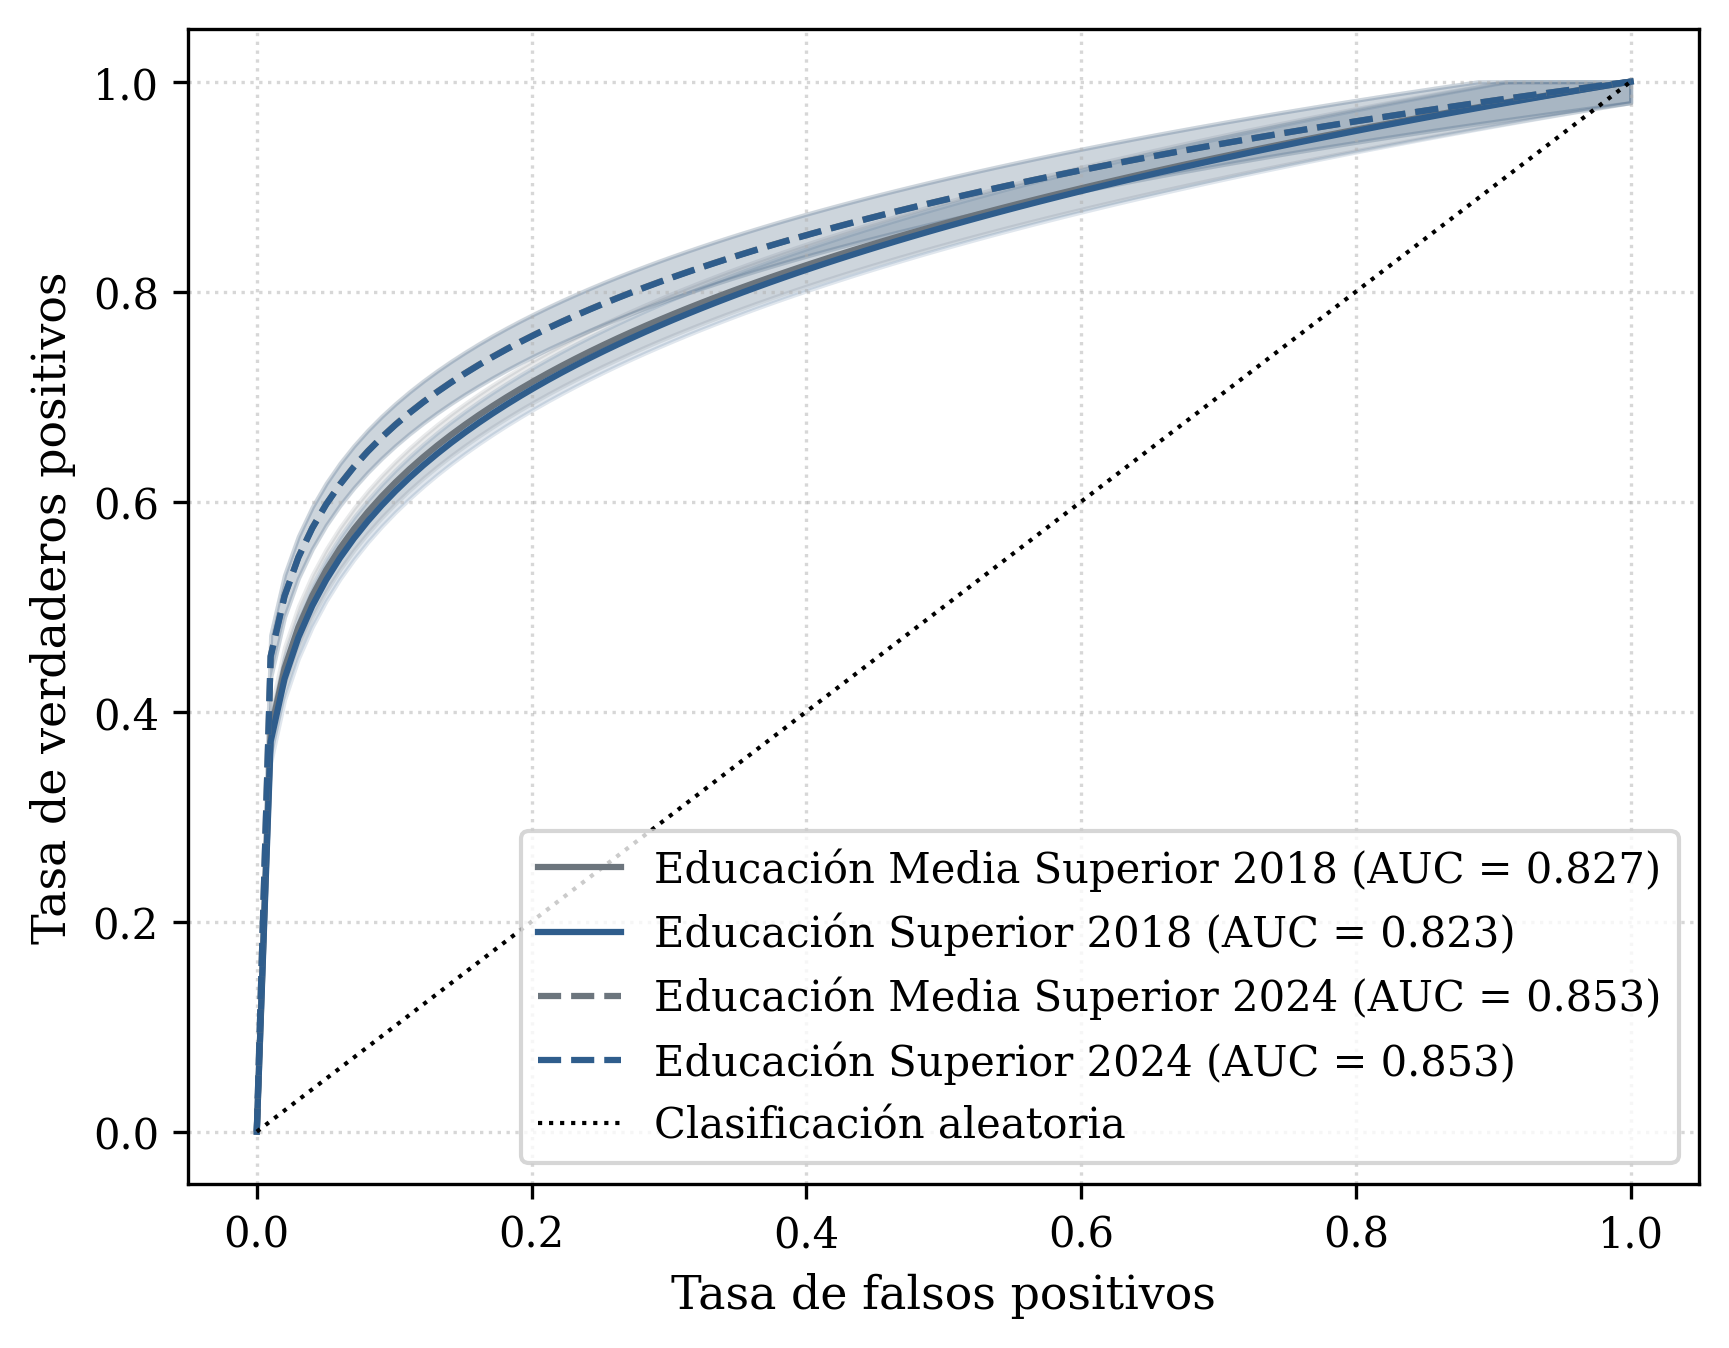

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '4.6'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# Colores fijos para las dos categorías
color_upper = '#6C757D'   # Media Superior
color_higher = '#2F5D8C'  # Superior

# =============================================
# FUNCIÓN PARA GENERAR COORDENADAS ROC
# =============================================
def get_roc_coords(auc):
    k = auc / (1 - auc)
    fpr = np.linspace(0, 1, 100)
    tpr = fpr ** (1 / k)
    return fpr, tpr

# =============================================
# DATOS DE AUC POR MODELO
# =============================================
aucs = {
    'Educación Media Superior 2018': 0.8267,
    'Educación Superior 2018': 0.8227,
    'Educación Media Superior 2024': 0.8530,
    'Educación Superior 2024': 0.8528
}

# =============================================
# CREACIÓN DE LA FIGURA
# =============================================
plt.figure(figsize=(6.5, 5))

for name, val in aucs.items():
    fpr, tpr = get_roc_coords(val)

    # Asignar color según nivel educativo
    color = color_upper if 'Media Superior' in name else color_higher
    # Asignar estilo de línea según año
    linestyle = '-' if '2018' in name else '--'

    # Banda de confianza ilustrativa (±2 puntos porcentuales)
    ci_margin = 0.02
    lower = np.maximum(0, tpr - ci_margin)
    upper = np.minimum(1, tpr + ci_margin)

    # Curva ROC
    plt.plot(fpr, tpr, color=color, linestyle=linestyle,
             linewidth=1.5, label=f"{name} (AUC = {val:.3f})")
    # Banda de confianza
    plt.fill_between(fpr, lower, upper, color=color, alpha=0.15)

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='black', linestyle=':', linewidth=1,
         label='Clasificación aleatoria')

# =============================================
# ETIQUETAS Y ESTILO
# =============================================
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')

# Leyenda con marco y ubicación automática
plt.legend(loc='lower right', frameon=True)

# Rejilla en ambos ejes
plt.grid(axis='both', linestyle=':', alpha=0.5)

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()